# Laboratorium 4 - rekomendacje dla portali informacyjnych

## Przygotowanie

 * pobierz i wypakuj dataset: https://mind201910small.blob.core.windows.net/release/MINDsmall_train.zip
   * więcej możesz poczytać tutaj: https://learn.microsoft.com/en-us/azure/open-datasets/dataset-microsoft-news
 * [opcjonalnie] Utwórz wirtualne środowisko
 `python3 -m venv ./recsyslab4`
 * zainstaluj potrzebne biblioteki:
 `pip install nltk sklearn`

In [1]:
!pip install nltk sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


## Część 1. - przygotowanie danych

In [2]:
# importujemy wszystkie potrzebne pakiety

import codecs
from collections import defaultdict # mozesz uzyc zamiast zwyklego slownika, rozwaz wplyw na czas obliczen
import math
import re
from string import punctuation

import nltk
nltk.download('stopwords')
nltk.download('rslp')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer
from nltk.stem import WordNetLemmatizer
from nltk.stem.lancaster import LancasterStemmer
from nltk.stem.porter import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

# mozesz uzyc do obliczania najbardziej podobnych tekstow zamiast liczenia "na piechote"
# ale pamietaj o dostosowaniu formatu danych
from sklearn.neighbors import NearestNeighbors

# na potrzeby wizualizacji
import matplotlib.pyplot as plt
from wordcloud import WordCloud

#inne
import numpy as np

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
# definiujemy potrzebne zmienne

PATH = './MINDsmall_train'
STOPWORDS = set(stopwords.words('english'))

In [4]:
# wczytujemy metadane artykulow

def parse_news_entry(entry):
    news_id, category, subcategory, title, abstract = entry.split('\t')[:5]
    return {
        'news_id': news_id,
        'category': category,
        'subcategory': subcategory,
        'title': title,
        'abstract': abstract
    }

def get_news_metadata():
    with codecs.open(f'{PATH}/news.tsv', 'r', 'UTF-8') as f:
        raw = [x for x in f.read().split('\n') if x]
        parsed_entries = [parse_news_entry(entry) for entry in raw]
        return {x['news_id']: x for x in parsed_entries}

news = get_news_metadata()
news_ids = sorted(list(news.keys()))
news_indices = {x[1]: x[0] for x in enumerate(news_ids)}
print(len(news))

51282


In [5]:
def parse_history_entry(entry):
    _id, user_id, _time, history, _impressions = entry.split('\t')
    history = [x for x in history.split() if x]
    return user_id, history

def get_users_history():
    with codecs.open(f'{PATH}/behaviors.tsv', 'r', 'UTF-8') as f:
        lines = [x for x in f.read().split('\n') if x]
        entries = [parse_history_entry(x) for x in lines]
        return dict(entries)

users_history = get_users_history()
test_users = 'U53231', 'U89744', 'U10045', 'U92486', 'U70879'
print(len(users_history))

50000


## Część 2. - TF-IDF

In [6]:
# normalizujemy teksty na potrzeby dalszego przetwarzania

def preprocess_text(text):
    # zamieniamy wszystkie ciagi bialych znakow na pojedyncze spacje
    text = ' '.join(text.split())
    # usuwamy znaki interpunkcyjne
    text = text.translate(str.maketrans('', '', punctuation))
    # usuwamy wszystkie liczby
    text = ''.join([i for i in text if not i.isdigit()])
    # podmieniamy wszystkie wielkie litery
    text = text.lower()
    # dzielimy na tokeny
    tokens = word_tokenize(text)
    # usuwamy stopwords
    filtered_sentence = [w for w in tokens if not w in STOPWORDS]
    return filtered_sentence

def stem_texts(corpus):
    stemmer = PorterStemmer()
    return [[stemmer.stem(word) for word in preprocess_text(text)] for text in corpus]

texts = [news[news_id]['abstract'] for news_id in news_ids]
stemmed_texts = stem_texts(texts)

In [7]:
# porownajmy teksty przed i po przetworzeniu

print(texts[2] + '\n')
print(' '.join(stemmed_texts[2]))

"I think we have a really good team, and a team that can really do some special, good things because that group is very close in there." - Brian Schmetzer

think realli good team team realli special good thing group close brian schmetzer


In [8]:
# tworzymy liste wszystkich slow w korpusie

def get_all_words_sorted(corpus):
    # generujemy posortowana alfabetycznie liste wszystkich slow (tokenow)
    sorted_words = set()
    for text in corpus:
        for token in text:
            sorted_words.add(token)
    sorted_list = sorted(list(sorted_words))
    return sorted_list

wordlist = get_all_words_sorted(stemmed_texts)
word_indices = {x[1]: x[0] for x in enumerate(wordlist)}
print(len(wordlist))

41881


In [9]:
# obliczamy liczbe tekstow, w ktorych wystapilo kazde ze slow
# pamietaj, ze jesli slowo wystapilo w danym tekscie wielokrotnie, to liczymy je tylko raz

def get_document_frequencies(corpus, wordlist):
    # return {word -> count}
    per_word_frequency = defaultdict(lambda: 0)
    for text in corpus:
        unique_words = set()
        for word in text:
            if word not in unique_words:
                per_word_frequency[word] += 1
                unique_words.add(word)
    return per_word_frequency

document_frequency = get_document_frequencies(stemmed_texts, wordlist)

In [10]:
# obliczamy liczbe wystapien kazdego slowa w kazdym tekscie

def get_term_frequencies(corpus, news_indices):
    # return {news_id -> {word -> count}}
    results = {news_id: defaultdict( lambda: 0) for news_id in news_indices}
    for news_id, index in news_indices.items():
        for word in corpus[index]:
            results[news_id][word] += 1
    return results

term_frequency = get_term_frequencies(stemmed_texts, news_indices)

In [11]:
# sprawdzmy wyniki

term_frequency[news_ids[2]]

defaultdict(<function __main__.get_term_frequencies.<locals>.<lambda>()>,
            {'think': 1,
             'realli': 2,
             'good': 2,
             'team': 2,
             'special': 1,
             'thing': 1,
             'group': 1,
             'close': 1,
             'brian': 1,
             'schmetzer': 1})

In [12]:
# obliczamy metryke tf_idf

def calculate_tf_idf(term_frequency, document_frequency, corpus_size):
    # return {news_id -> {word -> tf_idf}}
    results = {news_id: dict() for news_id in term_frequency}
    for news_id, count_per_word in term_frequency.items():
        for word, count in count_per_word.items():
            results[news_id][word] = count * math.log(corpus_size / document_frequency[word])
    return results

tf_idf = calculate_tf_idf(term_frequency, document_frequency, len(news_ids))

In [13]:
# sprawdzmy wyniki

tf_idf[news_ids[2]]

{'think': 4.360459856758821,
 'realli': 9.707261090572182,
 'good': 8.085400658139525,
 'team': 6.157356388748834,
 'special': 4.765161897298483,
 'thing': 4.111693200556713,
 'group': 4.261685870235309,
 'close': 3.9244235881453897,
 'brian': 5.624739267315748,
 'schmetzer': 9.458800731274183}

## Część 3. - Podobieństwo tekstów

In [14]:
# obliczmy odleglosc miedzy dwoma artykulami
# przetestuj rozne metryki odleglosci i wybierz najlepsza

def euklides_distance(tfidf_vector1, tfidf_vector2):
    return np.linalg.norm(np.array(tfidf_vector1) - np.array(tfidf_vector2))

def cosine_similarity(tfidf_vector1, tfidf_vector2):
    dot_product = np.dot(tfidf_vector1, tfidf_vector2)
    norm_vector1 = np.linalg.norm(tfidf_vector1)
    norm_vector2 = np.linalg.norm(tfidf_vector2)
    similarity = dot_product / (norm_vector1 * norm_vector2)
    return similarity

def calculate_distance(tf_idf, id1, id2, metric='cosine'):
    first_dict = tf_idf[id1]
    sec_dict = tf_idf[id2]
    all_words = set(list(first_dict.keys()) + list(sec_dict.keys()))
    first_vector = [first_dict.get(word, 0) for word in all_words]
    second_vector = [sec_dict.get(word, 0) for word in all_words]
    if metric == 'euklides':
        similarity_score = euklides_distance(first_vector, second_vector)
        return similarity_score
    elif metric == 'cosine':
        similarity_score = cosine_similarity(first_vector, second_vector)
        return similarity_score

calculate_distance(tf_idf, news_ids[2], news_ids[1])

np.float64(0.024674752325832595)

In [15]:
# funkcja pomocnicza do wyswietlania artykulow
def print_news_entry(n_id, corpus):
    print(f'id: {n_id}\n\ttitle: {corpus[n_id]["title"]}\n\ttext: {corpus[n_id]["abstract"]}')

print_news_entry('N42782', news)

id: N42782
	title: Three takeaways from Yankees' ALCS Game 5 victory over the Astros
	text: The Yankees kept hope alive thanks to some impressive starting pitching and a pair of early home runs.


In [16]:
# wyznaczmy k najpodobniejszych tekstow do danego
# pamietaj o odpowiedniej kolejnosci sortowania w zaleznosci od wykorzystanej metryki
# pamietaj, zeby wsrod podobnych tekstow nie bylo danego

def get_k_most_similar_news(tf_idf, n_id, k, metric='cosine'):
    scores = {}
    for news_id in tf_idf:
        if news_id != n_id:
            scores[news_id] = calculate_distance(tf_idf, n_id, news_id, metric=metric)
    results = [score[0] for score in sorted(scores.items(), key=lambda x: x[1], reverse=True if metric == 'cosine' else False)[:k]]
    return results

def print_k_most_similar_news(tf_idf, n_id, k, corpus, metric='cosine'):
    similar = get_k_most_similar_news(tf_idf, n_id, k, metric=metric)
    print_news_entry(n_id, corpus)
    print(f'\n{k} most similar ({metric} metric):')
    for s_id in similar:
       print_news_entry(s_id, corpus)

print_k_most_similar_news(tf_idf, news_ids[42337], 5, news)

/tmp/ipython-input-4141824524.py:11: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / (norm_vector1 * norm_vector2)


id: N58544
	title: Tiny Electric Car Cost $420,000 To Build
	text: A MAN claims he has created a car that might solve the world's traffic congestion problems. Rick Woodbury from Spokane, Washington USA, is the president, founder and sole employee of 'Commuter Cars.' The carmaker's flagship model is the 2005 super slim two-seater Tango T600, a high-performance electric car that preceded Tesla. Rick told BTV: "I started this company 21 years ago   it was based on an idea that I came up with in 1982." He was inspired by the shocking traffic congestion he had to face on a daily basis. "I used to drive a Porsche from Beverly Hills to Hermosa Beach every day and the traffic was horrendous," explained Rick. What really made Rick think about a solution was the fact that in most of the cars he would see in his commute were occupied by lone drivers. "I noticed that everybody around me was a single occupant in a car, taking up the whole lane," Rick said. Living and working in Los Angeles also hel

## Część 4. - Profile użytkowników

In [17]:
# oblicz srednia z wektorow tf-idf artykulow o zadanych id-kach
def calculate_average_vector(tf_idf, news_ids: list[str]) -> dict[str, float]:
    if not news_ids:
        return {}

    all_words = set()
    for n_id in news_ids:
        all_words.update(tf_idf[n_id].keys())

    average_vector = {}
    for word in all_words:
        total_tfidf = sum(tf_idf[n_id].get(word, 0) for n_id in news_ids)
        average_vector[word] = total_tfidf / len(news_ids)

    return average_vector

# wykorzystaj powyzsza funkcje, by policzyc wektor kazdego uzytkownika
def calculate_users_vectors(tf_idf, users_history) -> dict[str, dict[str, float]]:
    results = {}
    for user_id, history in users_history.items():
        results[user_id] = calculate_average_vector(tf_idf, history)
    return results

user_vectors = calculate_users_vectors(tf_idf, users_history)

In [18]:
# sprawdz wyliczony profil dla przykladowego uzytkownika
print(sorted([(k,v) for k,v in user_vectors[test_users[0]].items() if v], key=lambda x: -x[1]))

[('fire', 1.267870955689801), ('plane', 1.1701285777724966), ('ditch', 1.0497982187039419), ('diaz', 0.9848359105446637), ('land', 0.8870284483240061), ('paula', 0.8214687066477994), ('acr', 0.8090445060145697), ('ventura', 0.7780260164933531), ('mcconnel', 0.76945001209976), ('flight', 0.7527351413211081), ('maria', 0.7407074421074729), ('hailston', 0.7251391365595806), ('aircraft', 0.7197815043588195), ('storm', 0.6912488475417629), ('chaser', 0.6756286236624416), ('tornado', 0.6380084961613199), ('noaa', 0.6261181107653027), ('twoweek', 0.6177050367898467), ('airlin', 0.611710355929694), ('story', 0.6009271210247275), ('contain', 0.5981148110881273), ('california', 0.5954302330209911), ('santa', 0.5734321766843061), ('may', 0.5473113739405064), ('accord', 0.5430806765813037), ('ef', 0.5366350415870621), ('report', 0.5348199191461591), ('tanker', 0.5317069793379942), ('larg', 0.5301365597954284), ('alleg', 0.5258098807833907), ('mandatori', 0.5227667548412794), ('behind', 0.507174402

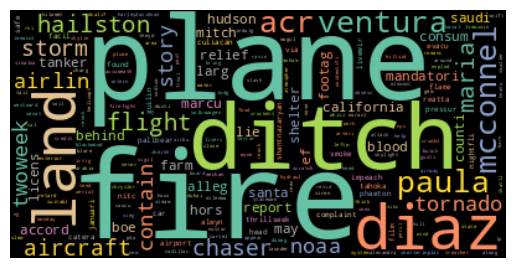

In [19]:
# skorzystajmy ze znanej juz biblioteki, by to lepiej zwizualizowac
def plot_vector(tf_idf_vector):
    wordcloud = WordCloud(random_state=42, background_color='black', colormap='Set2')
    wordcloud.generate_from_frequencies(frequencies=tf_idf_vector)
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

plot_vector(user_vectors[test_users[0]])

## Część 5. - Rekomendacje dla użytkowników

User history for U53231:
id: N58936
	title: Beloved grandfather's body pulled from collapsed Hard Rock hotel
	text: A family holding vigil outside the site of the Hard Rock hotel construction collapse received the news they hoped they'd never hear.
id: N15919
	title: Saddleridge fire calms down, heavy rains on East Coast
	text: A new storm system is developing in the southern Plains and will move east over the next few days bringing a threat of flooding to the South with rain and gusty winds.
id: N11917
	title: JetBlue Plane Makes Emergency Landing at JFK Airport
	text: The plane landed safely in NYC Sunday night.
id: N2153
	title: Iran alleges foreign government behind 'treacherous' ship attack
	text: Iran said Monday a foreign government was behind what it alleges was a "treacherous" attack on a tanker off Saudi Arabia last week, as it released pictures of its damaged hull. But the state-owned NITC denied reports the alleged attack had originated from Saudi soil.
id: N55312
	title: W

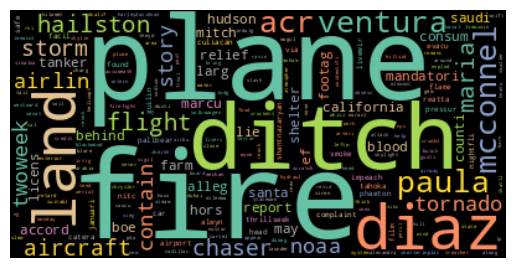



Top 5 recommendations for U53231:
id: N58169
	title: Helicopter crews take on California's Maria fire with nighttime flights
	text: Ventura County Fire crews battling the Maria Fire in California used nighttime helicopter flights to control the blaze, according to local authorities. "Helicopters that fight fire at night are not common. They take special knowledge, skills, training and technology," Ventura County Fire wrote on Twitter. The Maria Fire broke out in the hills above Santa Paula and began to spread on Thursday evening, October 31. By the evening of November 3, authorities said, the fire has grown to 9,412 acres but was 70 percent contained. Only two structures were destroyed by the fire, but widespread evacuation orders were in place. The Ventura County Sheriff said that 1,800 structures were threatened as the fire grew on October 31 and that 7,500 people were under evacuation orders. Credit: Ventura County Fire via Storyful
id: N58561
	title: Wildfire Alert Cameras Captur

In [20]:
# wykorzystujac wektory tresci i profile uzytkownikow,
#   wygeneruj liste k artykulow najlepiej dopasowanych do uzytkownika
#   pamietaj o odsianiu artykulow, ktore uzytkownik juz kliknal

def recommend(tf_idf, user_id, news, users_history, k, metric='cosine'):
    user_vector = user_vectors[user_id]
    user_history = users_history[user_id]
    scores = {}
    for news_id, news_vector in tf_idf.items():
        if news_id not in user_history:
            all_words = set(user_vector.keys()).union(set(news_vector.keys()))
            vec1 = [user_vector.get(word, 0) for word in all_words]
            vec2 = [news_vector.get(word, 0) for word in all_words]

            if metric == 'cosine':
                if np.linalg.norm(vec1) == 0 or np.linalg.norm(vec2) == 0:
                    scores[news_id] = 0
                else:
                    scores[news_id] = cosine_similarity(vec1, vec2)
            elif metric == 'euklides':
                 scores[news_id] = euklides_distance(vec1, vec2)

    recommended_news = [news_id for news_id, score in sorted(scores.items(), key=lambda item: item[1], reverse=True if metric == 'cosine' else False)[:k]]
    return recommended_news

# dla wybranego uzytkownika, korzystajac z juz zaimplementowanych funkcji,
#   pokaz jego historie, profil (wordcloud) i rekomendacje

test_user_id = test_users[0]
k_recommendations = 5

print(f"User history for {test_user_id}:")
for news_id in users_history[test_user_id]:
    print_news_entry(news_id, news)
print("\n")

print(f"User profile (WordCloud) for {test_user_id}:")
plot_vector(user_vectors[test_user_id])
print("\n")

print(f"Top {k_recommendations} recommendations for {test_user_id}:")
recommendations = recommend(tf_idf, test_user_id, news, users_history, k_recommendations)
for news_id in recommendations:
    print_news_entry(news_id, news)

## Część 6. - Ocena jakości

In [21]:
# jaccard index to metryka podobienstwa zbiorow, lekko ja zmodyfikujemy
# przeciecie wektorow to minimum po kazdej wspolrzednej
# unia wektorow to maksimum po kazdej wspolrzednej
# jaccard index to iloraz sum tych dwoch wartosci

def jaccard(v1, v2):
    all_keys = set(v1.keys()).union(set(v2.keys()))

    sum_min = sum(min(v1.get(key, 0), v2.get(key, 0)) for key in all_keys)
    sum_max = sum(max(v1.get(key, 0), v2.get(key, 0)) for key in all_keys)

    if sum_max == 0:
        return 0
    else:
        return sum_min / sum_max

In [22]:
# dla kazdego uzytkownika wygeneruj k-elementowa rekomendacje
# policz jaccard index miedzy wektorem uzytkownika a srednim wektorem elementow z rekomendacji
# porownaj wyniki dla dwoch roznych k i dwoch roznych metryk podobienstwa

def evaluate_recommendations(tf_idf, user_vectors, news, users_history, test_users, k_values, metrics_to_test):
    results = {}
    for user_id in test_users:
        results[user_id] = {}
        user_vector = user_vectors[user_id]
        for metric in metrics_to_test:
            results[user_id][metric] = {}
            for k in k_values:
                recommendations = recommend(tf_idf, user_id, news, users_history, k, metric=metric)
                recommended_news_vectors = {news_id: tf_idf[news_id] for news_id in recommendations}
                average_recommended_vector = calculate_average_vector(recommended_news_vectors, recommendations)
                jaccard_score = jaccard(user_vector, average_recommended_vector)
                results[user_id][metric][k] = jaccard_score
    return results

k_values_to_test = [5, 10]
metrics_to_test = ['cosine', 'euklides']

evaluation_results = evaluate_recommendations(tf_idf, user_vectors, news, users_history, test_users, k_values_to_test, metrics_to_test)

print("Jaccard Index for User Profiles and Recommended Items' Average Vectors:")
for user_id, metric_scores in evaluation_results.items():
    print(f"User: {user_id}")
    for metric, scores in metric_scores.items():
        print(f"  Metric: {metric}")
        for k, score in scores.items():
            print(f"    k={k}: {score:.4f}")

Jaccard Index for User Profiles and Recommended Items' Average Vectors:
User: U53231
  Metric: cosine
    k=5: 0.0535
    k=10: 0.0780
  Metric: euklides
    k=5: 0.0000
    k=10: 0.0000
User: U89744
  Metric: cosine
    k=5: 0.0386
    k=10: 0.0529
  Metric: euklides
    k=5: 0.0000
    k=10: 0.0000
User: U10045
  Metric: cosine
    k=5: 0.0528
    k=10: 0.0629
  Metric: euklides
    k=5: 0.0000
    k=10: 0.0000
User: U92486
  Metric: cosine
    k=5: 0.0455
    k=10: 0.0580
  Metric: euklides
    k=5: 0.0000
    k=10: 0.0000
User: U70879
  Metric: cosine
    k=5: 0.0342
    k=10: 0.0538
  Metric: euklides
    k=5: 0.0000
    k=10: 0.0000
